In [1]:
import tensorflow
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense,Flatten

In [2]:
(x_train,y_train),(x_test,y_test) = keras.datasets.mnist.load_data()

In [3]:
x_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [4]:
x_train.shape
# This shows that we have 60000 images, and each image is 28 by 28 pixels. 
# So we have 60000 samples, and each sample has 784 features (28*28=784) because we will flatten the images into a one-dimensional array of pixel values.

(60000, 28, 28)

In [5]:
x_train[0].shape
# Shape of first image

(28, 28)

In [6]:
x_test.shape
# We have 10000 test samples, and each sample is also a 28 by 28 pixel image.

(10000, 28, 28)

In [7]:
y_train
# These are the labels for the training data, which represent the digit (0-9) that each image corresponds to.

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

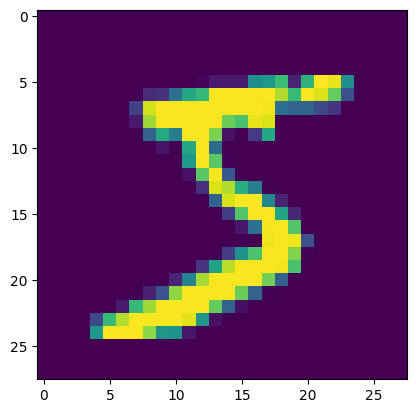

In [8]:
import matplotlib.pyplot as plt
plt.imshow(x_train[0])

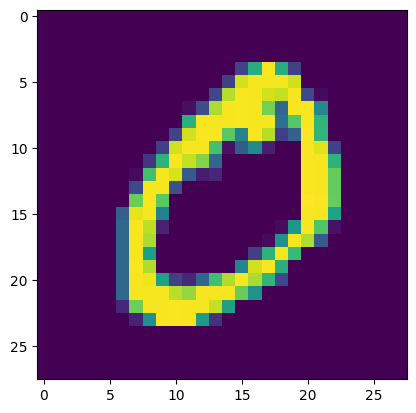

In [9]:
plt.imshow(x_train[1])

In [10]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [11]:
# Here we can see the pixel values of the first image, which are integers between 0 and 255.
# First we need to scale down to the range of 0 to 1 by dividing by 255.
# Because the more the value in one range the more faster the weight are calculated. 

In [12]:
x_train = x_train / 255
x_test = x_test / 255

In [13]:
x_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [14]:
model = Sequential()

# since the data is in 2d -> 28,28 we need to flatten it to 1d -> 784
# For this keras provides a layer called Flatten which will take care of this for us.

model.add(Flatten(input_shape=(28,28)))
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(10,activation='softmax'))

In [15]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 10)                650       
                                                                 
Total params: 109,386
Trainable params: 109,386
Non-trainable params: 0
_________________________________________________________________


In [16]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
# Difference between sparse_categorical_crossentropy and categorical_crossentropy is that->
# In sparse_categorical_crossentropy -> no need to one-hot encode the labels
# In categorical_crossentropy -> need to one-hot encode the labels

In [17]:
history = model.fit(x_train,y_train,epochs=25,validation_split=0.2)

Epoch 1/25
1500/1500 [==============================] - 7s 4ms/step - loss: 0.2635 - accuracy: 0.9218 - val_loss: 0.1383 - val_accuracy: 0.9583
Epoch 2/25
1500/1500 [==============================] - 5s 3ms/step - loss: 0.1099 - accuracy: 0.9671 - val_loss: 0.1125 - val_accuracy: 0.9677
Epoch 3/25
1500/1500 [==============================] - 6s 4ms/step - loss: 0.0772 - accuracy: 0.9757 - val_loss: 0.0899 - val_accuracy: 0.9745
Epoch 4/25
1500/1500 [==============================] - 10s 7ms/step - loss: 0.0564 - accuracy: 0.9827 - val_loss: 0.1071 - val_accuracy: 0.9693
Epoch 5/25
1500/1500 [==============================] - 7s 5ms/step - loss: 0.0454 - accuracy: 0.9853 - val_loss: 0.0902 - val_accuracy: 0.9742
Epoch 6/25
1500/1500 [==============================] - 7s 5ms/step - loss: 0.0347 - accuracy: 0.9887 - val_loss: 0.0964 - val_accuracy: 0.9743
Epoch 7/25
1500/1500 [==============================] - 8s 5ms/step - loss: 0.0294 - accuracy: 0.9902 - val_loss: 0.1011 - val_accuracy

In [17]:
y_prob = model.predict(x_test)
# Here we predict the probabilities for each class (0-9) for each test sample.

313/313 [==============================] - 1s 2ms/step


In [18]:
y_pred = y_prob.argmax(axis=1)
# Here we take the index of the highest probability for each test sample, which gives us the predicted class (digit) for each sample.

In [19]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

ModuleNotFoundError: No module named 'sklearn'

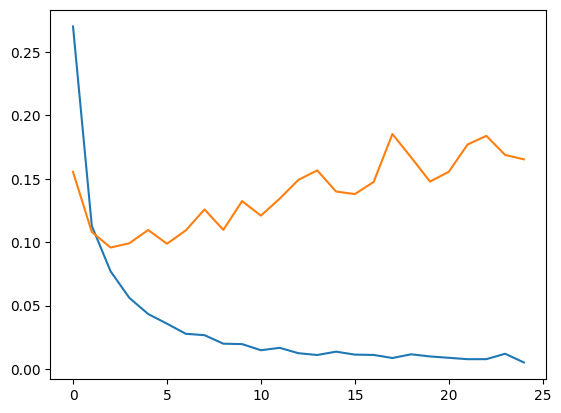

In [73]:
# Draw graph
plt.plot(history.history['loss'],label='train_loss')
plt.plot(history.history['val_loss'],label='val_loss')

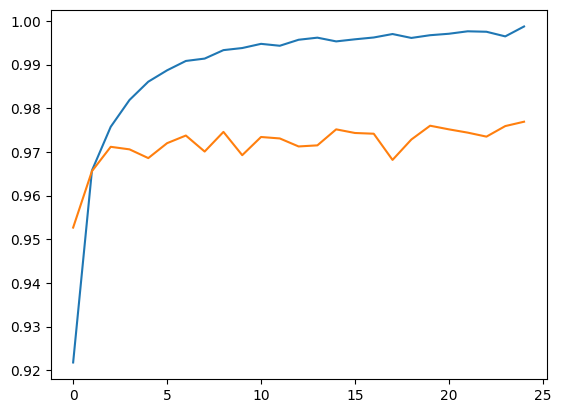

In [74]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

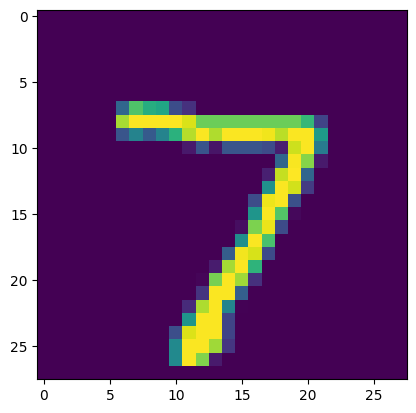

In [75]:
plt.imshow(x_test[0])

In [76]:
model.predict(x_test[0].reshape(1,28,28)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


array([7], dtype=int64)

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-